# Plot surface parameters
- This script is used to visualize urban fraction and prescribed roof albedo.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import string
from matplotlib.colors import ListedColormap
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
home_path = '/gws/ssde/j25a/duicv/yuansun/'
file_date = '250811'
albedo_date = '250812'
domain = 'HK'

In [2]:
gpd_hk = gpd.read_file(f'{home_path}0_wrf-cstm_GM-HK/HK/mask/boundary/hk_boundary.shp')
gpd_hk = gpd_hk.to_crs(epsg=4326)

In [3]:
var = 'dyn_alb_roof_MD'
roof_albedo_first_HK = xr.open_dataset('data_for_figure/roof_albedo_first_HK.nc')[var]
roof_albedo_last_HK = xr.open_dataset('data_for_figure/roof_albedo_last_HK.nc')[var]
data_list = [roof_albedo_first_HK, roof_albedo_last_HK]
df_albedo = pd.read_csv('data_for_figure/sum_roof_albedo_area.csv')
df_albedo.head()

,time,sum_roof_albedo_area,domain
0,2034-01-01,4.810689,HK
1,2034-02-01,4.810689,HK
2,2034-03-01,4.810689,HK
3,2034-04-01,4.810689,HK
4,2034-05-01,4.810689,HK


In [4]:
ds_mask = xr.open_dataset(f'{home_path}0_wrf-cstm_GM-HK/{domain}/mask/mask_{domain}.nc')
ds_mask

<xarray.Dataset> Size: 33kB
Dimensions:    (lsmlat: 60, lsmlon: 60)
Coordinates:
  * lsmlat     (lsmlat) int64 480B 0 1 2 3 4 5 6 7 8 ... 52 53 54 55 56 57 58 59
  * lsmlon     (lsmlon) int64 480B 0 1 2 3 4 5 6 7 8 ... 52 53 54 55 56 57 58 59
Data variables:
    mask       (lsmlat, lsmlon) bool 4kB ...
    PCT_URBAN  (lsmlat, lsmlon) float64 29kB ...

In [5]:
ds_surf = xr.open_dataset(f'{home_path}0_wrf-cstm_GM-HK/{domain}/surface_data/usurf/Usurf_surfdata_{domain}_1.2x1.2_SSP5-8.5_2035_78pfts_c{file_date}.nc')
urban_area = 1.44 * ds_surf['PCT_URBAN'][2] / 100 #  * ds_surf['LANDFRAC_PFT']
roof_area = (urban_area * ds_surf['WTLUNIT_ROOF'][2]).where(ds_mask['mask'], 0)
lat_hk = ds_surf['LATIXY'][:, 0].values
lon_hk = ds_surf['LONGXY'][0, :].values
extent_hk = [lon_hk.min(), lon_hk.max(), lat_hk.min(), lat_hk.max()]

In [6]:
ds_albedo_stream = xr.open_dataset(f'{home_path}0_wrf-cstm_GM-HK/{domain}/surface_data/usurf/dyn_alb_roof_{domain}_1.2x1.2_2034-2042_c{albedo_date}.nc')
roof_albedo_tv = ds_albedo_stream[var]
roof_albedo_tv_modified = roof_albedo_tv.rename({'lat': 'lsmlat', 'lon': 'lsmlon'}).assign_coords({'lsmlat': ds_mask.lsmlat, 'lsmlon': ds_mask.lsmlon})
ds_albedo_stream_last = roof_albedo_tv_modified[-1].where(urban_area>0).where(ds_mask['mask'])
ds_albedo_stream_first = roof_albedo_tv_modified[0].where(urban_area>0).where(ds_mask['mask'])
ds_albedo_stream_last_modified = ds_albedo_stream_last.rename({'lsmlat': 'lat', 'lsmlon': 'lon'}).assign_coords({'lat': roof_albedo_tv.lat, 'lon': roof_albedo_tv.lon})
ds_albedo_stream_first_modified = ds_albedo_stream_first.rename({'lsmlat': 'lat', 'lsmlon': 'lon'}).assign_coords({'lat': roof_albedo_tv.lat, 'lon': roof_albedo_tv.lon})
normalized_roof_albedo_first = (ds_albedo_stream_first * roof_area).sum().values / roof_area.sum().values
normalized_roof_albedo_last = (ds_albedo_stream_last * roof_area).sum().values / roof_area.sum().values
normalized_roof_albedo_area = [normalized_roof_albedo_first, normalized_roof_albedo_last]
print(f'{domain}: {np.round(normalized_roof_albedo_first,3)}, {np.round(normalized_roof_albedo_last,3)}')

HK: 0.162, 0.9


In [7]:
np.unique(ds_surf['ALB_ROOF_DIR'][0,2,20:30].where(ds_surf['ALB_ROOF_DIR'][0,2,20:30]>0))

array([0.06941291, 0.16190283, 0.16190283, 0.16190283])

In [8]:
nrow=1
ncol=2
boundarywidth = 0.5
labelcolor = '#6b6b6b'
labelsize = 6
padding = 4
proj = ccrs.PlateCarree()
title_list = ['Percentage of urban area', 'Transient roof albedo']
cbar_pad = -0.05
cbar_aspect = 15
cbar_shrink = 0.4
tick_length = 4
ticklabel_pad = 0.2
linewdith = 0.5
marker = 'o'
marker_size = 3
domain_land = xr.open_dataset('../../HK/surface_data/domain.lnd.wrf2clm_lnd_noneg_wrf2clm_ocn_noneg.250815.nc')
ds_lnd_domain= domain_land['mask'].rename({'ni': 'lsmlon', 'nj': 'lsmlat'})
ds_domain_urban = ds_surf['PCT_URBAN'][2].where(ds_lnd_domain == 1, np.nan)

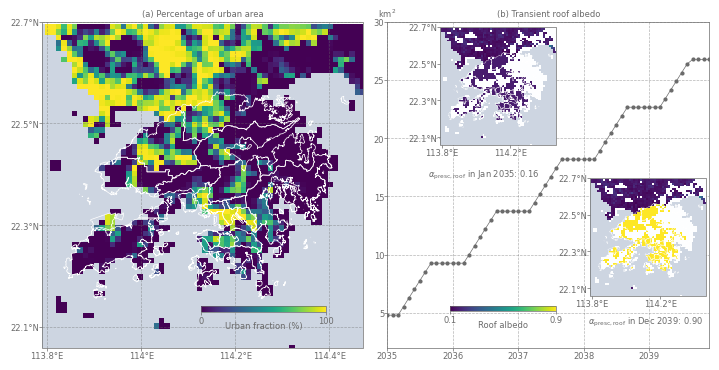

In [9]:
fig = plt.figure(figsize=(7.1,3.5))
ax1 = fig.add_subplot(1,2,1, projection=proj)
ax2 = fig.add_subplot(1,2,2)
ax = [ax1, ax2]
for i in range(nrow*ncol):
    if i == 0:
        vmin = 0
        vmax = 100
        gpd_hk.plot(ax=ax[i], facecolor='none', edgecolor='white', lw=0.5, zorder=2)
        cm = ax[i].pcolormesh(lon_hk, lat_hk, ds_domain_urban, cmap='viridis', vmin=0, vmax=100, transform=proj, zorder=1)
        cm_ocean = ax[i].pcolormesh(lon_hk, lat_hk, ds_lnd_domain==0, cmap='Blues', alpha=0.2, transform=proj, zorder=0)
        ax[i].set_extent(extent_hk, crs=proj)
        xticks = np.arange(extent_hk[0], extent_hk[1], 0.2)
        xticks_round1 = np.round(xticks, 1)
        ax[i].set_xticks(xticks_round1, crs=proj)
        #ax[i].set_xticklabels([f"{x:.1f}" for x in xticks], fontsize=labelsize, color=labelcolor)
        ax[i].xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))    
        yticks = np.arange(extent_hk[2], extent_hk[3], 0.2)
        yticks_round1 = np.round(yticks, 1)
        ax[i].set_yticks(yticks_round1, crs = proj) 
        #ax[i].set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=labelsize, color=labelcolor)
        ax[i].yaxis.set_major_formatter(LatitudeFormatter())
        cbar1 = plt.colorbar(cm, ax=ax, orientation='horizontal', ticks=[vmin, vmax],  extend='neither')
        cbar1.set_label('Urban fraction (%)', fontsize=labelsize, color=labelcolor, labelpad=-3)
        offset_text = cbar1.ax.yaxis.get_offset_text()
        offset_text.set(size=labelsize, color=labelcolor)
        offset_text.set_position((5, 2))
        cbar1.ax.tick_params(length=2,labelsize=labelsize, pad = 1, width=boundarywidth, colors=labelcolor)
        cbar1.outline.set_linewidth(boundarywidth)
        cbar1.outline.set_edgecolor(labelcolor)
        cbar1.ax.yaxis.label.set_color(labelcolor)
        cbar1.ax.set_position([0.275, 0.05, 0.175, 0.1])
    elif i == 1:
        vmin = 0.1
        vmax = 0.9
        df_albedo['time'] = pd.to_datetime(df_albedo['time'])
        ax[i].plot(df_albedo['time'], df_albedo['sum_roof_albedo_area'], linewidth=linewdith, color=labelcolor,
                     marker = marker, markersize=marker_size, markerfacecolor=labelcolor, markeredgewidth=0.5, markeredgecolor='none')
        ax[i].set_ylim(2, 30)
        ax[i].set_xlim(pd.Timestamp('2035-01-01'), pd.Timestamp('2039-12-01'))
        ax[i].set_xticks(pd.date_range('2035-01-01', '2039-12-01', freq='1YS'))
        ax[i].set_xticklabels(pd.date_range('2035-01-01', '2039-12-01', freq='1YS').year, rotation=0, ha='center')
        ax[i].set_ylabel('$\mathrm{km}^2$', fontsize=labelsize, labelpad=5, rotation=0, ha='center', color=labelcolor)
        ax[i].yaxis.set_label_coords(0, 1.0075)
        
        for j in range(2):
            date = ['Jan 2035', 'Dec 2039'][j]
            normalize_albedo_value = normalized_roof_albedo_area[j]
            ax[i].text([0.125, 0.625][j], [0.525, 0.075][j], rf'$\alpha_\mathrm{{presc,roof}}$ in {date}: {normalize_albedo_value:.2f}', 
                         fontsize=labelsize, color=labelcolor, transform=ax[i].transAxes)
                         
        bbox = ax[i].get_position()    
        for index_time in range(2):
            roof_albedo = data_list[index_time]
            inset_left   = bbox.x0 + [0.1, 0.7][index_time] * bbox.width
            inset_bottom = bbox.y0 + [0.5, -0.3][index_time] * bbox.height
            inset_width  = 0.625 * bbox.width
            inset_height = 0.625 * bbox.height
            position = [inset_left, inset_bottom, inset_width, inset_height]
            ax2 = fig.add_axes(position , projection=proj)
            for spine in ax2.spines.values():
                spine.set_linewidth(boundarywidth)
                spine.set_edgecolor(labelcolor) 
            gpd_hk.plot(ax=ax2, facecolor='none', edgecolor='white', lw=0.25, zorder=2)
            lat = roof_albedo.lat.values
            lon = roof_albedo.lon.values
            cm_ocean = ax2.pcolormesh(lon, lat, ds_lnd_domain==0, cmap='Blues', alpha=0.2, transform=proj, zorder=0)
            cm = ax2.pcolormesh(roof_albedo.lon, roof_albedo.lat,  roof_albedo,
                            cmap='viridis', vmin=vmin, vmax=vmax, transform=proj)   
            ax2.tick_params(axis='y', labelleft = True, labelsize=labelsize, length=tick_length/2, pad=ticklabel_pad, width=boundarywidth, colors=labelcolor)
            ax2.tick_params(axis='x', labelbottom = True, labelsize=labelsize, length=tick_length/2, pad=ticklabel_pad, width=boundarywidth, colors=labelcolor)  
            extent = [lon.min()-360, lon.max()-360, lat.min(), lat.max()]
            ax2.set_extent(extent, crs=proj)
            ax2.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False)) 
            ax2.yaxis.set_major_formatter(LatitudeFormatter())   
            sub_yticks = np.arange(extent[2], extent[3], 0.2)
            yticks_round1 = np.round(sub_yticks, 1)
            ax2.set_yticks(yticks_round1, crs = proj) 
            if i ==1:
                sub_xticks = np.arange(extent[0]+360, extent[1]+360, 0.4)
            else:    
                sub_xticks = np.arange(extent[0], extent[1], 0.4)
            xticks_round1 = np.round(sub_xticks, 1)
            ax2.set_xticks(xticks_round1, crs = proj)
        cbar2 = plt.colorbar(cm, ax=ax, orientation='horizontal',ticks=[vmin, vmax], extend='neither') # 'min'
        cbar2.set_label('Roof albedo', fontsize=labelsize, color=labelcolor, labelpad=-3)
        offset_text = cbar2.ax.yaxis.get_offset_text()
        offset_text.set(size=labelsize, color=labelcolor)
        offset_text.set_position((5, 2))
        cbar2.ax.tick_params(length=2,labelsize=labelsize, pad = 1, width=boundarywidth, colors=labelcolor)
        cbar2.outline.set_linewidth(boundarywidth)
        cbar2.outline.set_edgecolor(labelcolor)
        cbar2.ax.yaxis.label.set_color(labelcolor)
        cbar2.ax.set_position([0.625, 0.05, 0.15, 0.1])
    for spine in ax[i].spines.values():
        spine.set_linewidth(boundarywidth)
        spine.set_edgecolor(labelcolor)      
    ax[i].set_title(f'({string.ascii_lowercase[i]}) {title_list[i]}', fontsize=labelsize, color=labelcolor, pad=padding)  
    ax[i].tick_params(axis='y', labelleft = True, labelsize=labelsize, length=tick_length/2, pad=ticklabel_pad, width=boundarywidth, colors=labelcolor)
    ax[i].tick_params(axis='x', labelbottom = True, labelsize=labelsize, length=tick_length/2, pad=ticklabel_pad, width=boundarywidth, colors=labelcolor)    
    ax[i].grid('both', color=labelcolor, linestyle='--', linewidth=linewdith, alpha=0.5)

plt.subplots_adjust(left=0.05, right=0.99, bottom=0.03, top=0.9625, wspace=0.075, hspace=0.1)          
plt.savefig('study_area_urban.png', dpi=300)
plt.savefig('study_area_urban.pdf', dpi=600)

# Description

In [8]:
urban_area_sum = (1.44 * ds_surf['PCT_URBAN'][2]/100).where(ds_mask['mask']).sum().values
print(np.round(urban_area_sum, 1))

261.9


In [5]:
np.round(roof_area.sum().item(), 1) 

np.float64(29.7)

In [26]:
np.round(roof_area.sum()/ 30, 2)

<xarray.DataArray ()> Size: 8B
array(0.99)

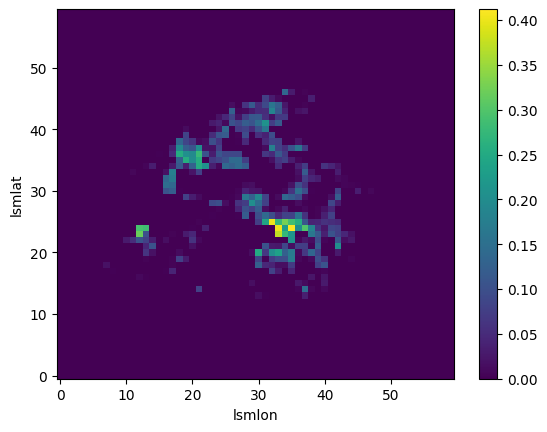

In [10]:
roof_area.plot()

<xarray.DataArray 'WTLUNIT_ROOF' ()> Size: 8B
array(0.00015472) <xarray.DataArray 'WTLUNIT_ROOF' ()> Size: 8B
array(0.30714877)


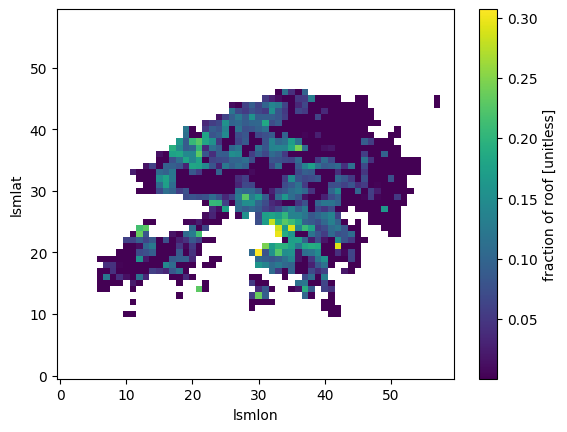

In [63]:
hk_roof_fraction = ds_surf['WTLUNIT_ROOF'][2].where(ds_mask['mask'], np.nan)
hk_roof_fraction.plot()
print(hk_roof_fraction.min(), hk_roof_fraction.max())